In [1]:
!git clone https://github.com/sashaLitv/Quantum-Test-Tasks.git

Cloning into 'Quantum-Test-Tasks'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 72 (delta 19), reused 64 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 4.57 MiB | 15.99 MiB/s, done.
Resolving deltas: 100% (19/19), done.


In [2]:
## delete unnecessary
!rm -rf "/kaggle/working/Quantum-Test-Tasks/Natural Language Processing. Named entity recognition"
!rm -rf "/kaggle/working/Quantum-Test-Tasks/.git"

In [3]:
import os
target_dir = '/kaggle/working/Quantum-Test-Tasks/Computer vision. Sentinel-2 image matching'
os.chdir(target_dir)

!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 23.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 33.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 17.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 3.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 4.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 20.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 5.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━

In [4]:
import sys

target_dir = "/kaggle/working/Quantum-Test-Tasks/Computer vision. Sentinel-2 image matching/src"
sys.path.insert(0, target_dir)
    
from algorithm_creation import ImagePreprocessor, SatelliteMatcher
from model_inference import MatchingPipeline

In [5]:
import re
from collections import defaultdict

location_groups = defaultdict(list)

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('_TCI.jp2'):
            full_path = os.path.join(dirname, filename)
            
            match = re.search(r'_(T\d{2}[A-Z]{3})_', full_path)
            
            if match:
                tile_id = match.group(1) 
                location_groups[tile_id].append(full_path)

image_pairs = []

for tile_id, paths in location_groups.items():
    sorted_paths = sorted(paths)
    
    for i in range(len(sorted_paths) - 1):
        image_pairs.append((sorted_paths[i], sorted_paths[i+1]))

print(f"Unique location: {len(location_groups)} (Tiles: {list(location_groups.keys())})")

📍 Unique location: 2 (Tiles: ['T36UYA', 'T36UXA'])


In [6]:
import torch

print("GPU availability:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU доступний: True
Назва GPU: Tesla T4


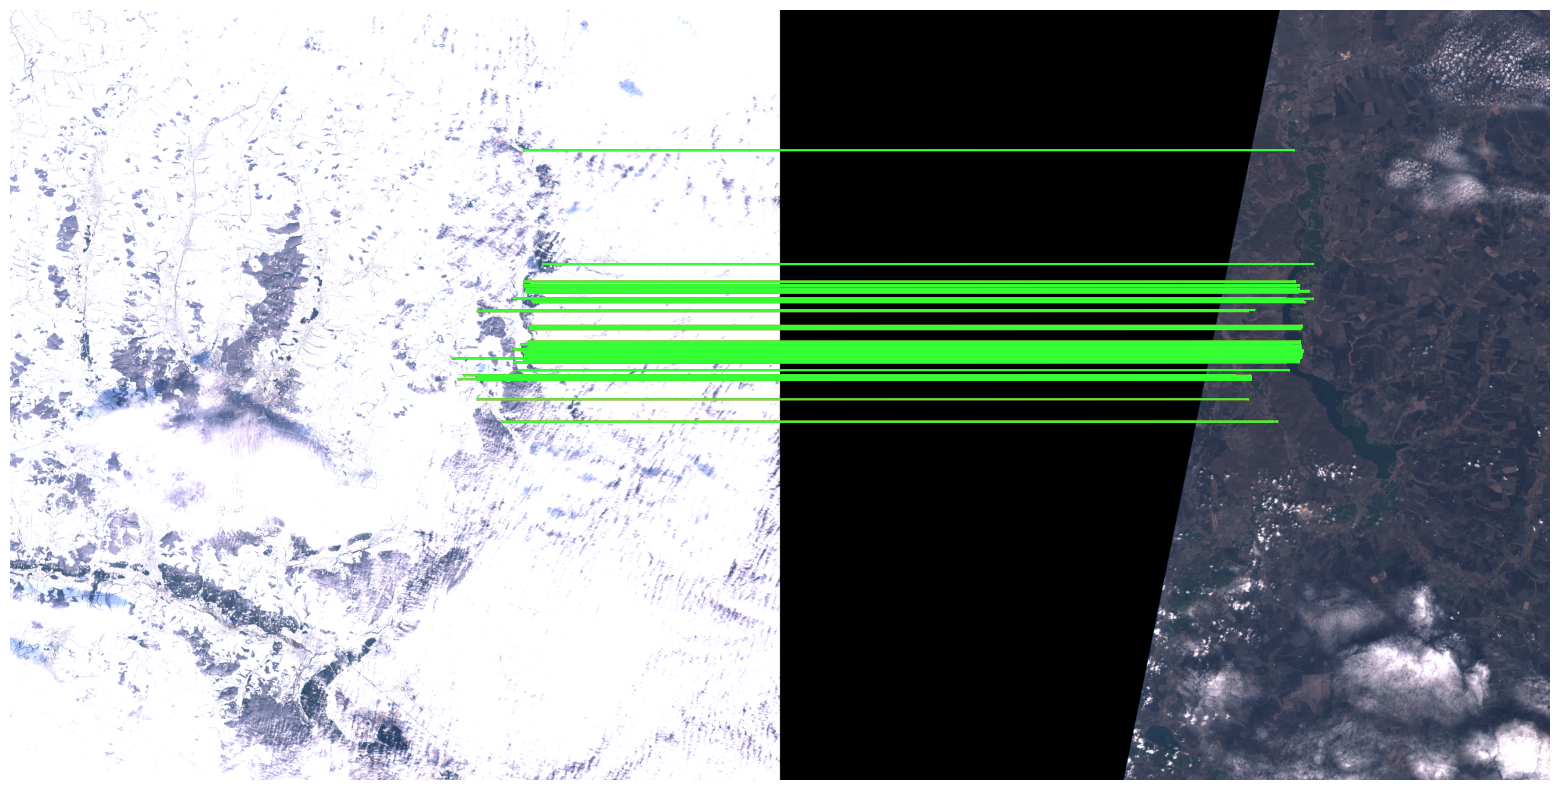

In [13]:
## one test with visualization
pipeline = MatchingPipeline(tile_size=512, ransac_threshold=3.0, device="cuda:0")

result = pipeline(image_pairs[0][0], image_pairs[0][1])

pipeline.draw_matches(
    matches=result, 
    show_outliers=True,    
    max_points=200,        
    strategy="best" 
)

In [11]:
# Process sequential pairs images in dataset 
## evaluate raw LoFTR matches using the USAC_MAGSAC algorithm to filter outliers and 
## calculate the exact number of true inliers.
import numpy as np
from concurrent.futures import ThreadPoolExecutor 

def process_pairs(pairs, device):
    pipeline = MatchingPipeline(tile_size=512, ransac_threshold=3.0,device=device) 
    statistics = []

    for idx, (img1, img2) in pairs:
        try:
            result = pipeline(img1, img2)

            if result.is_empty:
                statistics.append({
                    'pair_index': idx,
                    'img1': os.path.basename(img1),
                    'img2': os.path.basename(img2),
                    'total_matches': 0,
                    'inliers': 0,
                    'outliers': 0
                })
                continue

            total_matches = len(result.pts0)
            mask = result.inliers_mask

            if mask is None or len(mask) != total_matches:
                inliers_count = total_matches
                outliers_count = 0
            else:
                inliers_count = int(np.sum(mask))
                outliers_count = int(np.sum(~mask))

            statistics.append({
                'pair_index': idx,
                'img1': os.path.basename(img1),
                'img2': os.path.basename(img2),
                'total_matches': total_matches,
                'inliers': inliers_count,
                'outliers': outliers_count
            })

        except Exception as e:
            print(f"Pair {idx}: {e}")

    return statistics

indexed_pairs = list(enumerate(image_pairs))
mid = len(indexed_pairs) // 2

pairs_gpu0 = indexed_pairs[:mid]
pairs_gpu1 = indexed_pairs[mid:]

with ThreadPoolExecutor(max_workers=2) as executor:
    future0 = executor.submit(process_pairs, pairs_gpu0, "cuda:0")
    future1 = executor.submit(process_pairs, pairs_gpu1, "cuda:1")

    all_statistics = future0.result() + future1.result()

all_statistics.sort(key=lambda x: x["pair_index"])

In [12]:
import pandas as pd

df_stats = pd.DataFrame(all_statistics)

summary_metrics = {
    "": ["Mean", "Std"],
    "Total_matches": [df_stats['total_matches'].mean(), df_stats['total_matches'].std()],
    "Inliers": [df_stats['inliers'].mean(), df_stats['inliers'].std()],
    "Outliers": [df_stats['outliers'].mean(), df_stats['outliers'].std()]
}

df_summary = pd.DataFrame(summary_metrics)

print("\nSummary (Mean ± Std):")
display(df_summary)


Summary (Mean ± Std):


,,Total_matches,Inliers,Outliers
0,Mean,687193.937500,665879.520833,21314.416667
1,Std,478208.234374,481661.784873,13527.475179
